--- Metrics for Sea State 0 ---
RMSE Position (m): 0.013008
RMSE Velocity (m/s): 0.013970
Mean Extracted Power (W): 1062.84
Mean Stiffness K (N/m): 631200.00
Variance of Stiffness K (N^2/m^2): 35746560000.00
Number of K switches: 12
Maximum PTO Force (N): 424795.86
RMS PTO Force (N): 92022.52
--- Metrics for Sea State 1 ---
RMSE Position (m): 0.268852
RMSE Velocity (m/s): 0.176314
Mean Extracted Power (W): 143268.77
Mean Stiffness K (N/m): 893520.00
Variance of Stiffness K (N^2/m^2): 183154809600.00
Number of K switches: 67
Maximum PTO Force (N): 4001121.00
RMS PTO Force (N): 1067952.84
--- Metrics for Sea State 2 ---
RMSE Position (m): 0.028390
RMSE Velocity (m/s): 0.022421
Mean Extracted Power (W): 848.15
Mean Stiffness K (N/m): 630000.00
Variance of Stiffness K (N^2/m^2): 35100000000.00
Number of K switches: 16
Maximum PTO Force (N): 325972.14
RMS PTO Force (N): 89843.20
--- Metrics for Sea State 3 ---
RMSE Position (m): 0.283716
RMSE Velocity (m/s): 0.142930
Mean Extracted Power (W

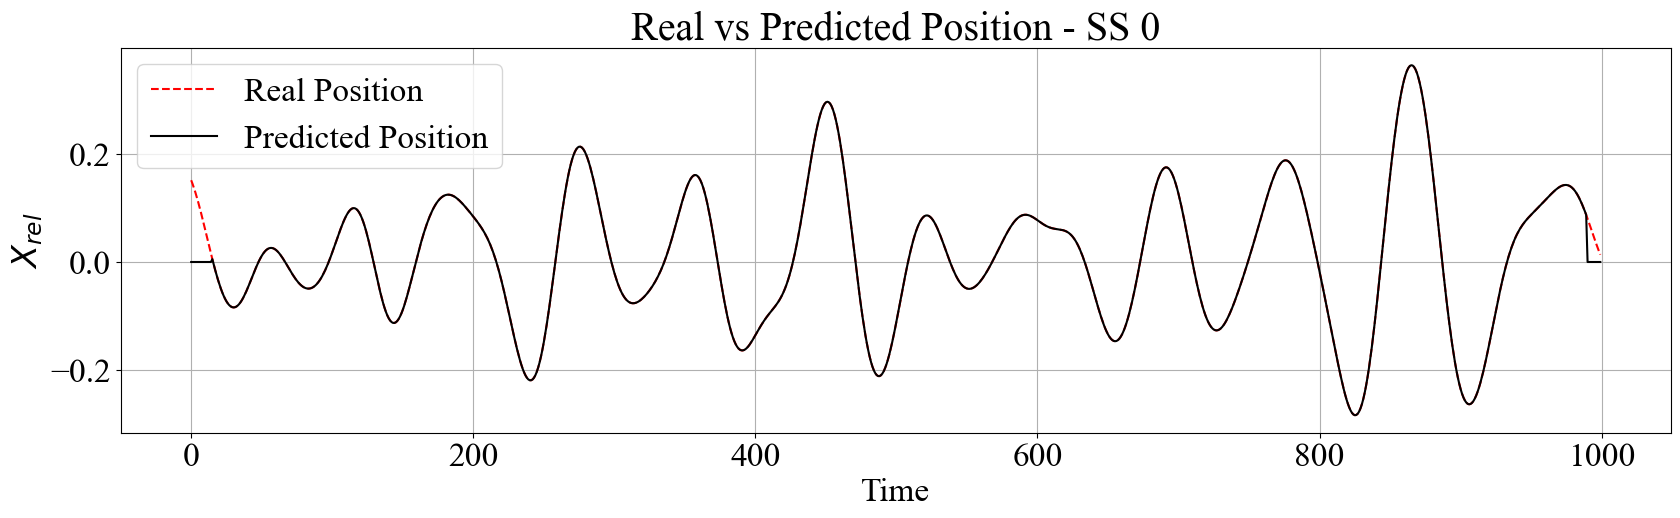

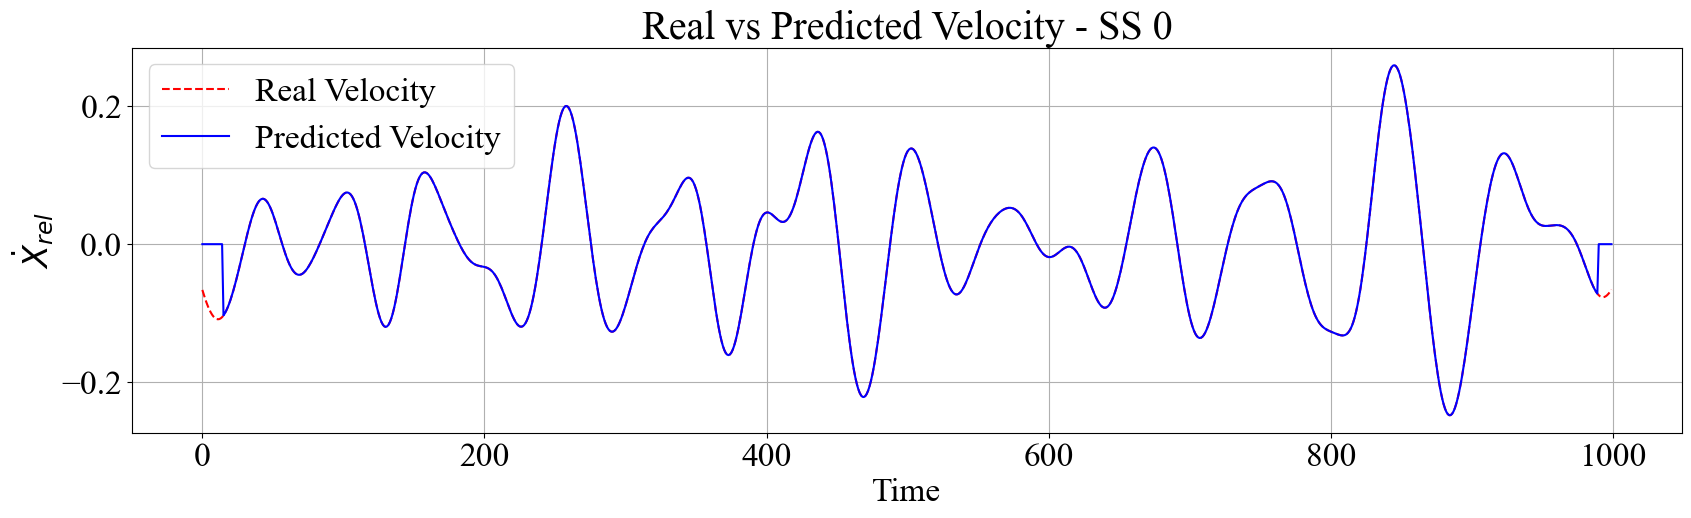

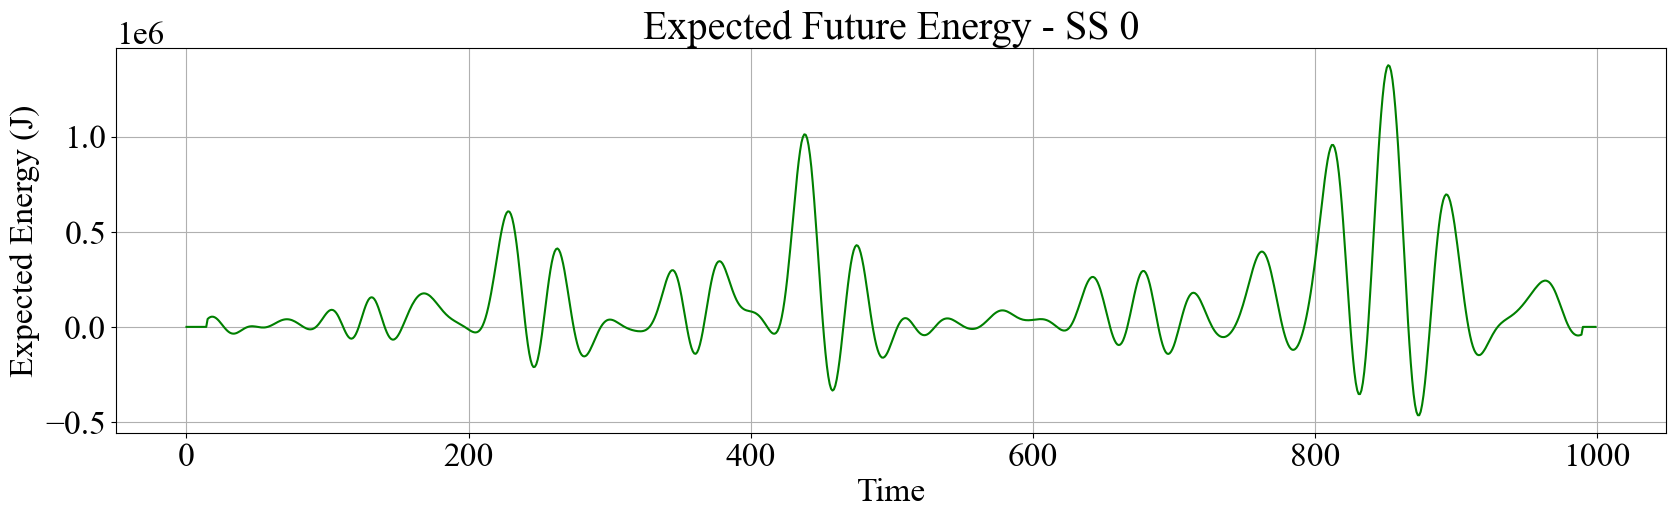

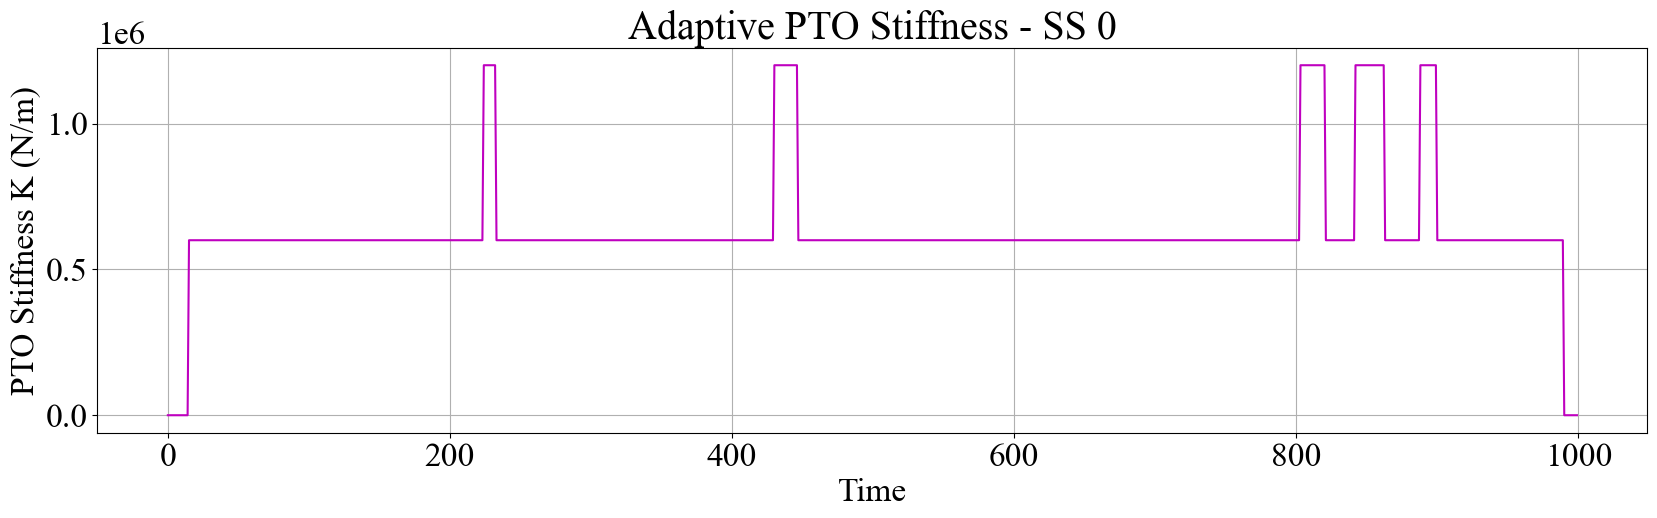

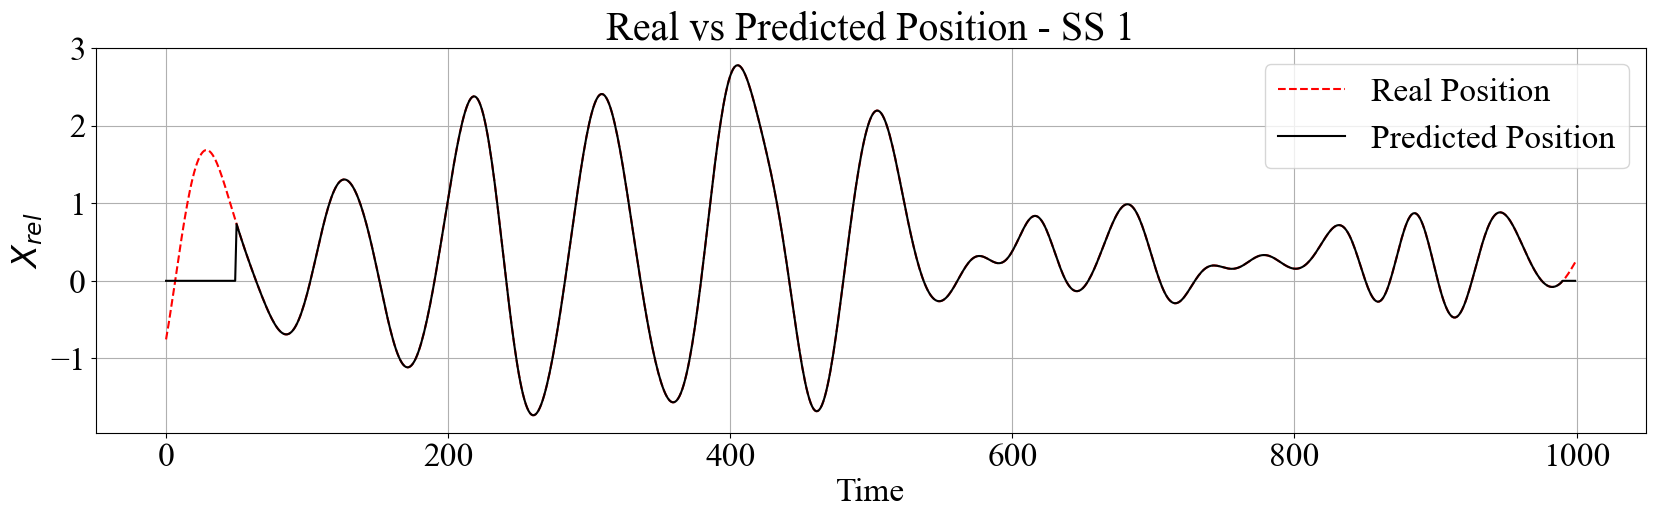

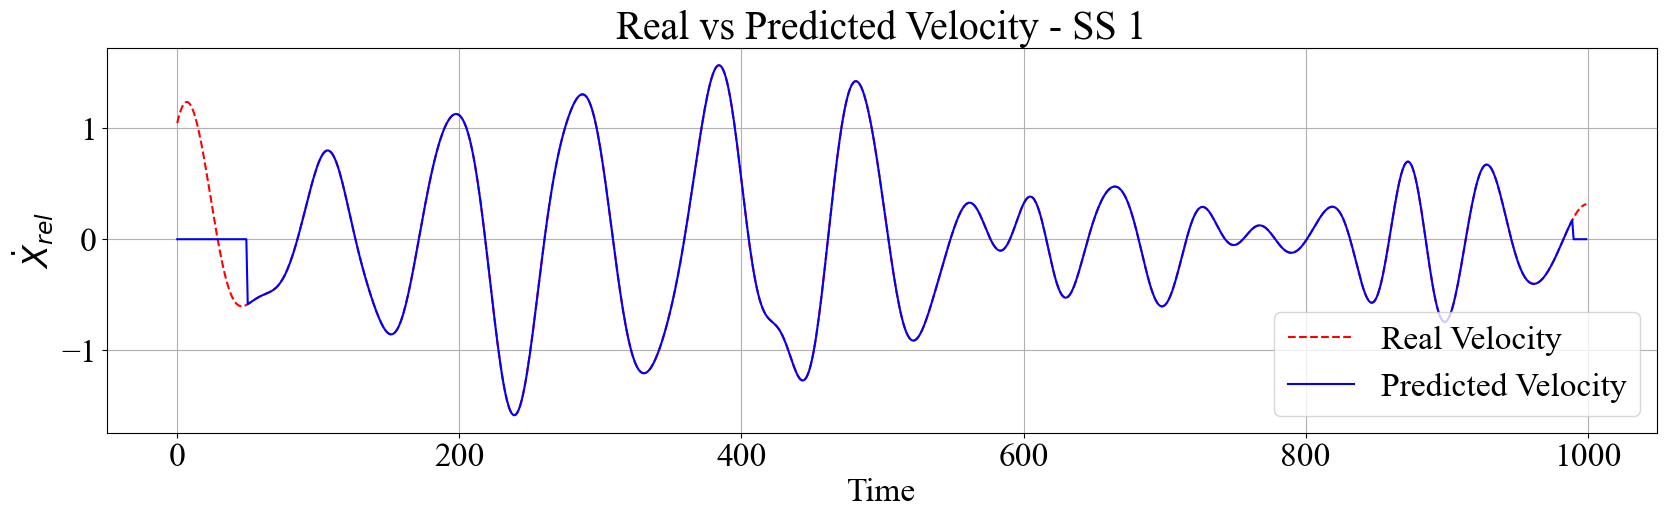

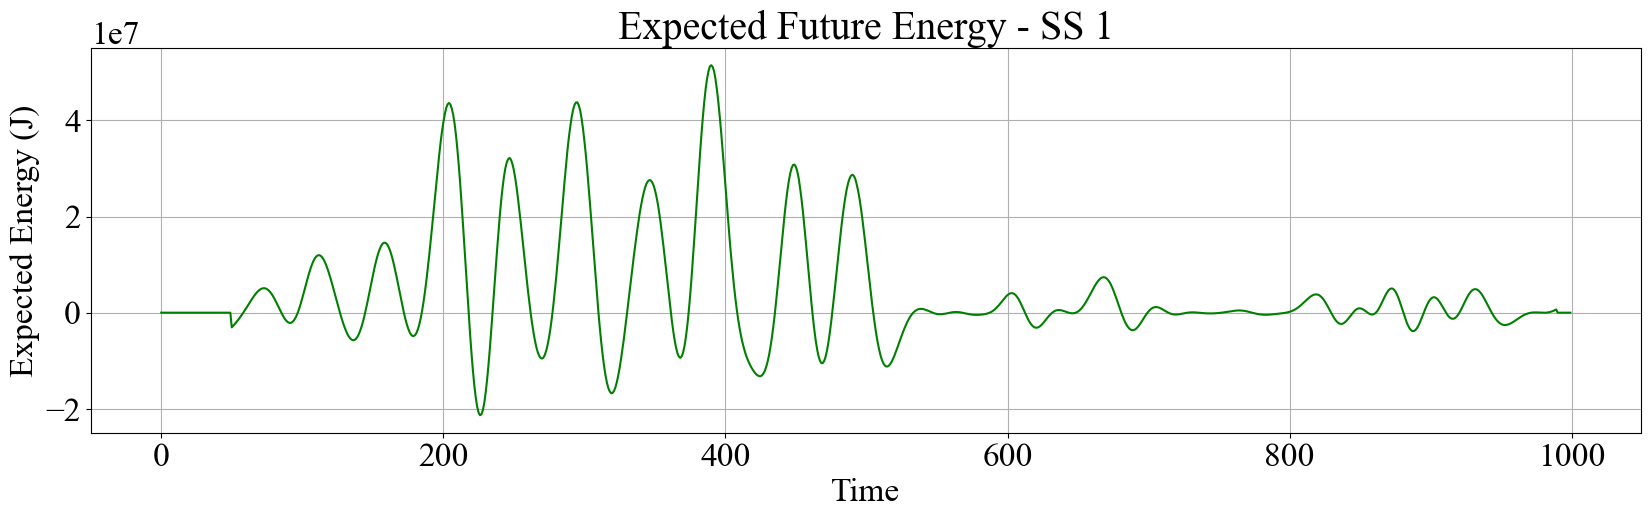

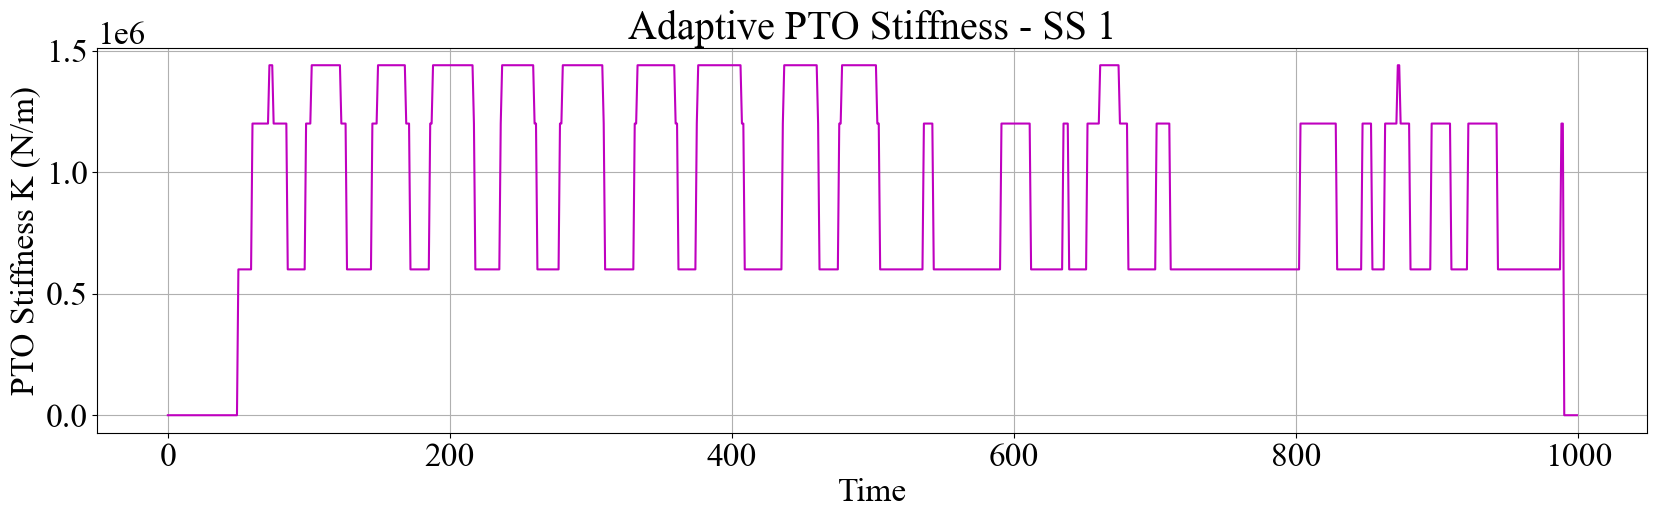

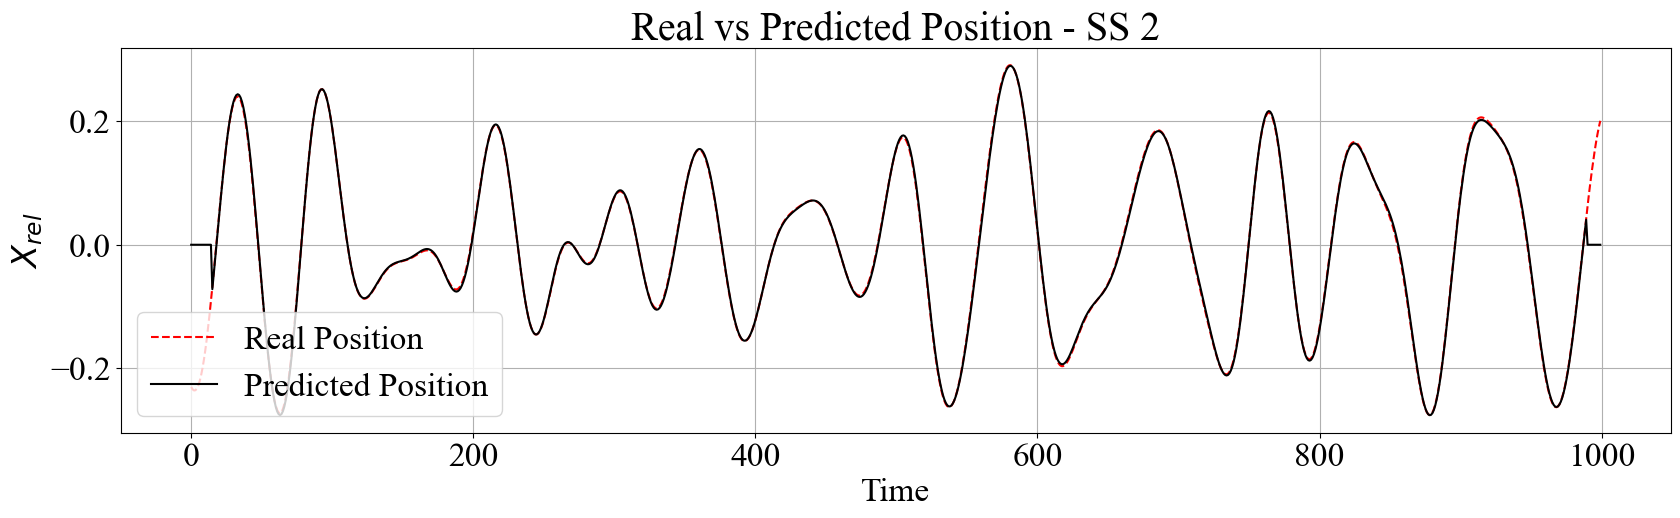

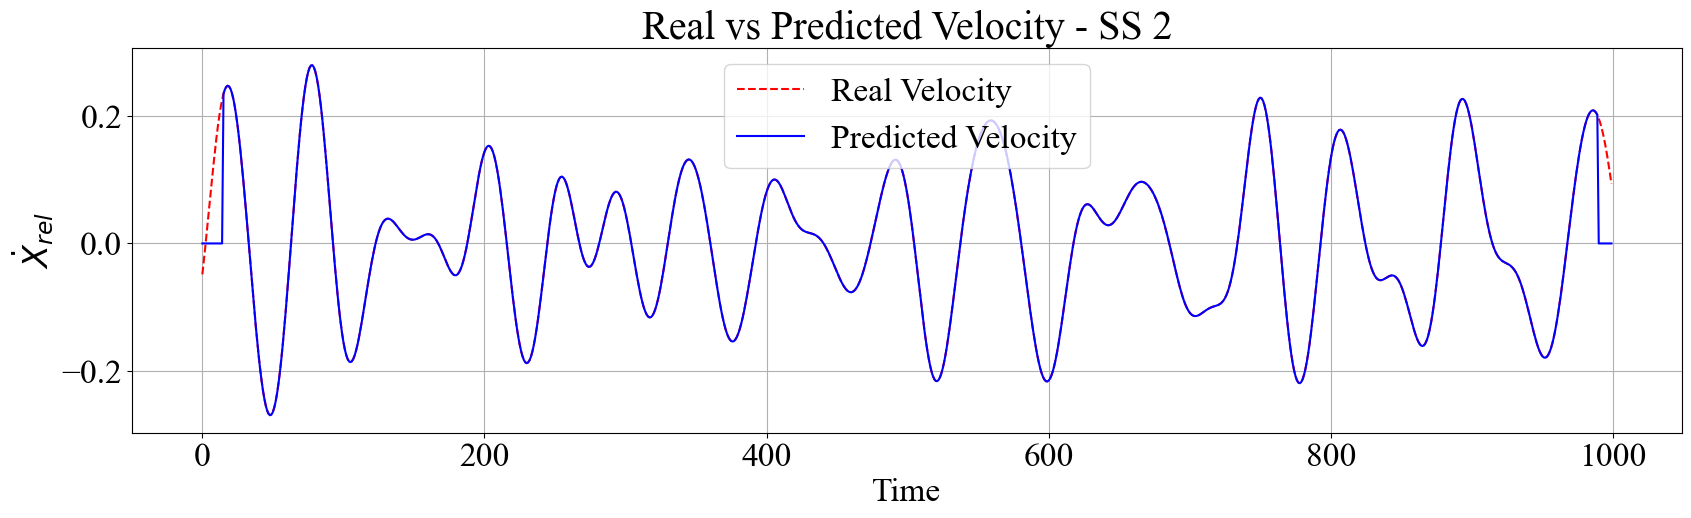

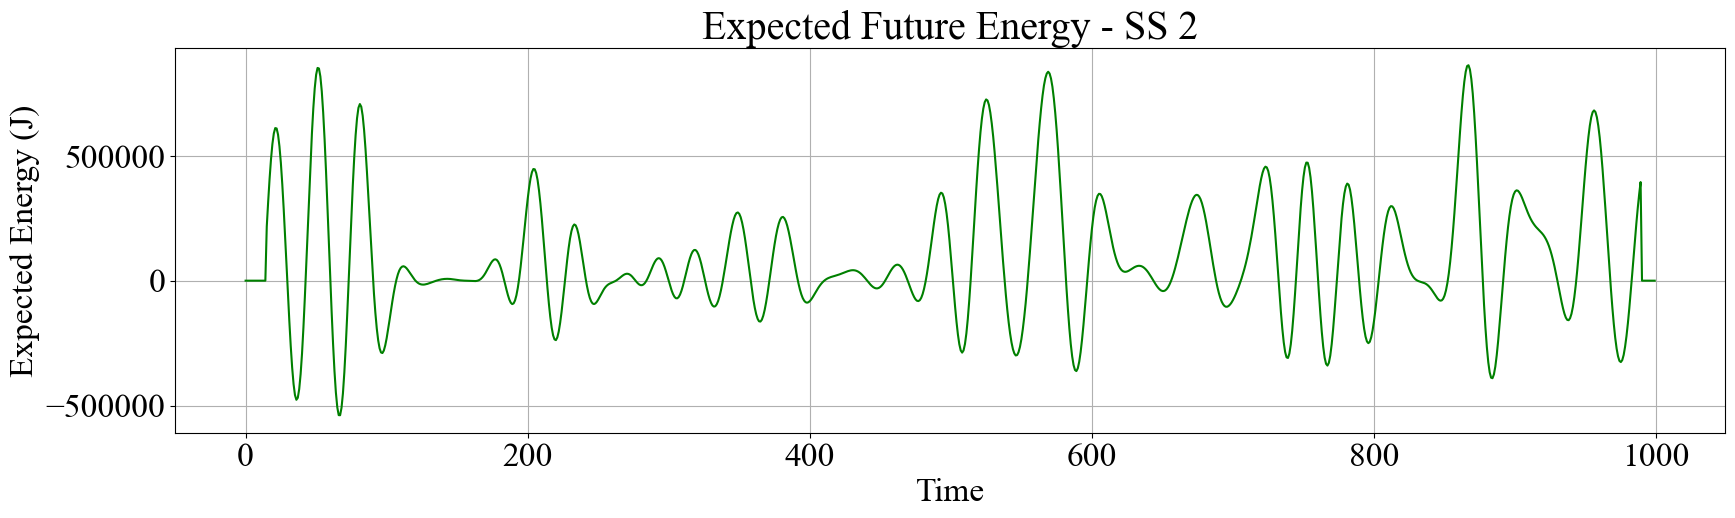

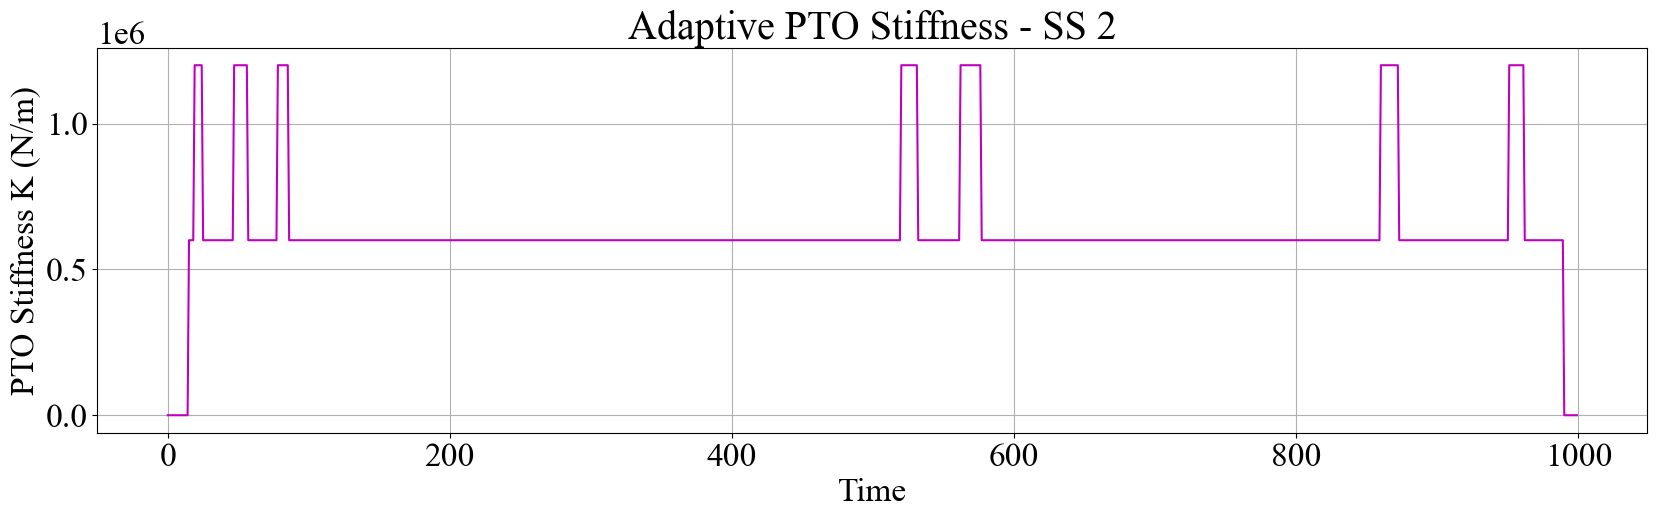

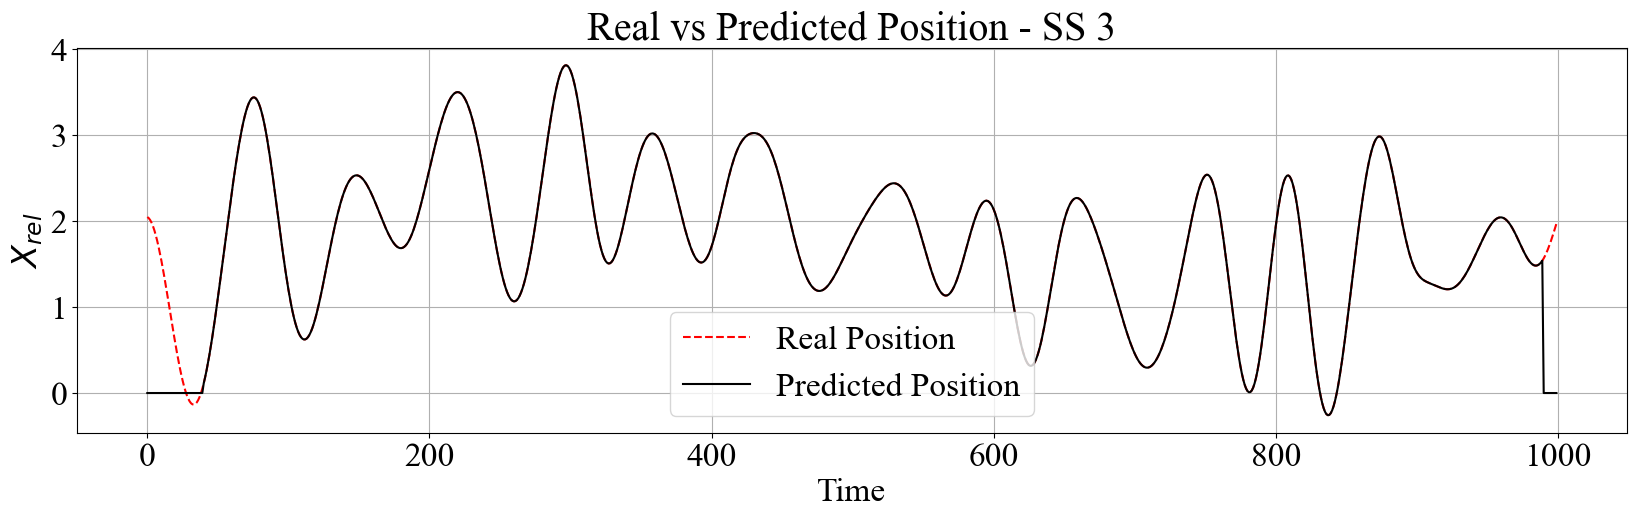

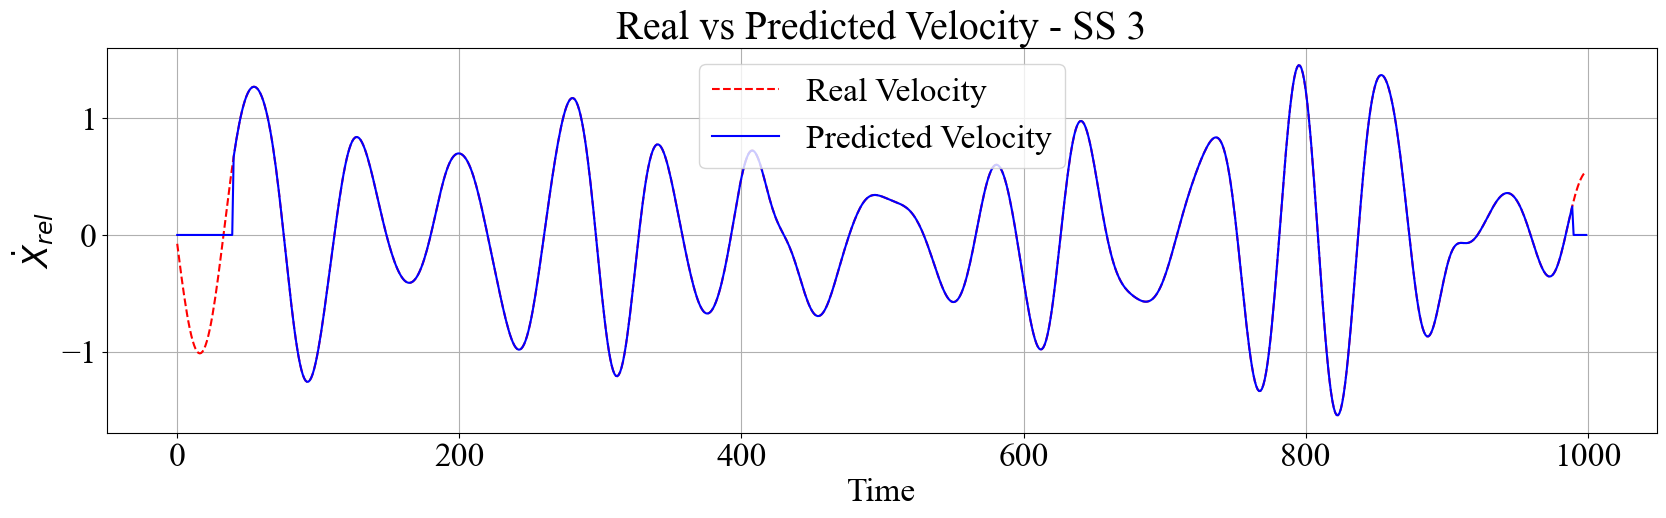

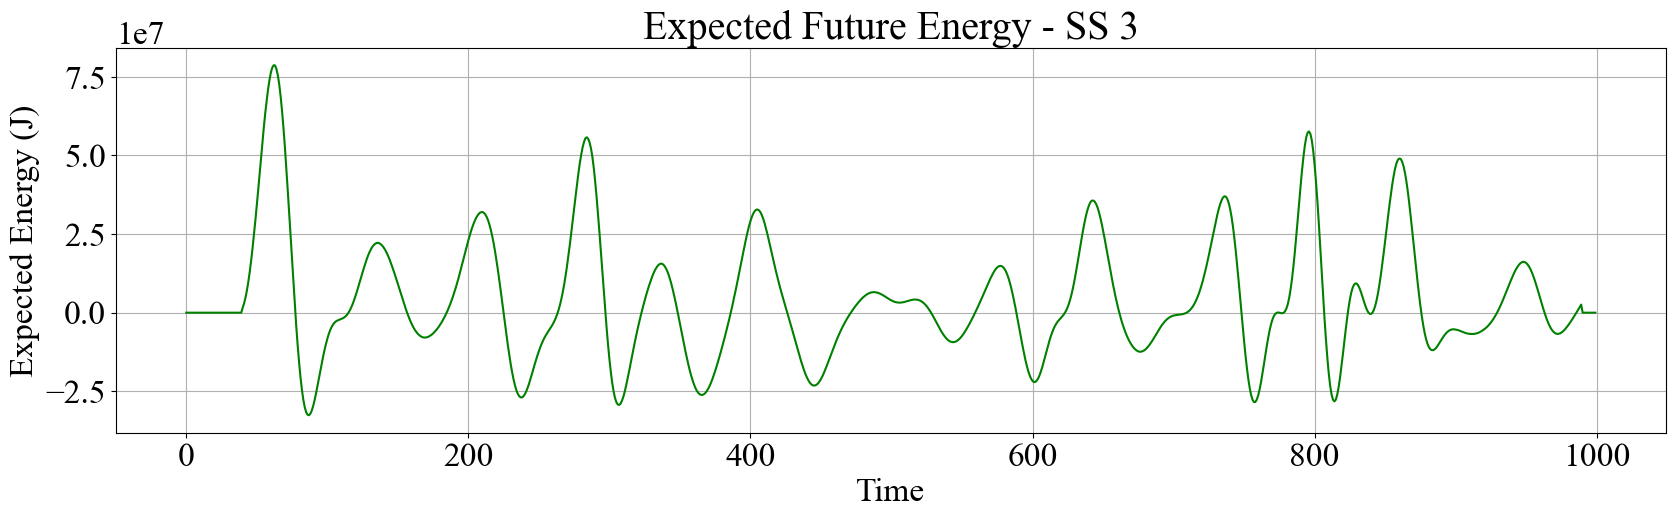

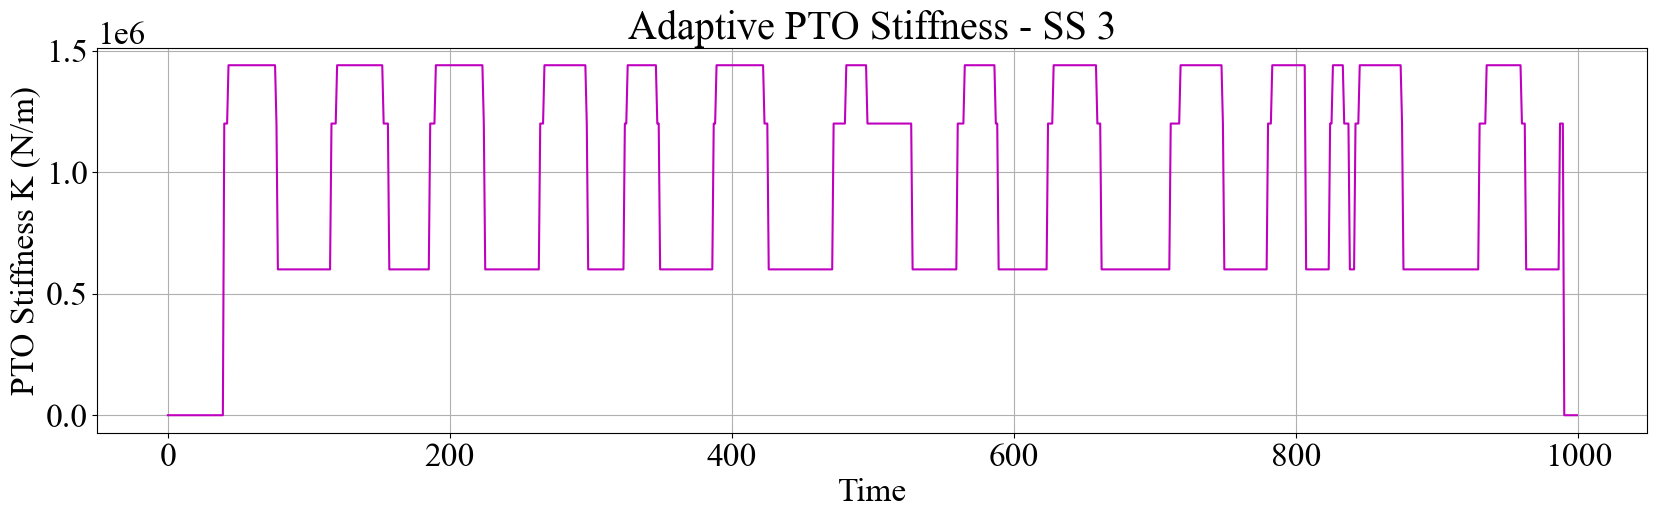

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Set font globally
plt.rcParams.update({'font.family': 'Times New Roman', 'font.size': 24})

# Define function to apply the NARMAX model for prediction
def predict_narmax(initial_conditions, x_future, equation, max_lag, prediction_horizon):
    y_pred = np.zeros(prediction_horizon + max_lag)
    y_pred[:max_lag] = initial_conditions[-max_lag:]  # Set initial conditions from real data

    for t in range(max_lag, prediction_horizon + max_lag):
        local_vars = {"t": t, "y_p": y_pred, "y_v": y_pred, "x1": np.concatenate((initial_conditions, x_future))}
        y_pred[t] = eval(equation, {}, local_vars)
    return y_pred[max_lag:]  # Return only predicted part

# Define function to calculate expected energy for a given K
def calculate_expected_energy(position_prediction, velocity_prediction, K):
    power = K * position_prediction * velocity_prediction
    energy = np.sum(power)
    return energy

# Parameters
prediction_horizon = 10  # N steps ahead
K_base = 1.2e6  # Base stiffness value (N/m)


# List of sea states with equations
sea_states = [
    {"Hs": 1.2, "Tp": 10, "file": "data1_1p2Hs_10Tp.csv", "max_lag_p": 15, "max_lag_v": 15,
     "p_eq": "(2.1629E+00 * y_p[t-1] - 6.2796E-01 * y_p[t-2] - 6.9201E-01 * y_p[t-3] - 2.1411E-01 * y_p[t-8] - 3.4218E-01 * y_p[t-4] + 1.0749E-01 * y_p[t-7] + 1.3620E-01 * y_p[t-5] + 7.9959E-09 * x1[t-1] - 8.8702E-09 * x1[t-2] + 9.2127E-10 * x1[t-11] + 4.6966E-01 * y_p[t-6])", 
     "v_eq": "(1.9363E+00 * y_v[t-1] - 1.7379E-01 * y_v[t-2] - 6.3815E-01 * y_v[t-3] + 2.6514E-01 * y_v[t-7] - 3.4732E-02 * y_v[t-15] - 1.3355E-01 * y_v[t-5] + 1.2761E-01 * y_v[t-14] + 2.1416E-02 * y_v[t-10] + 2.8224E-01 * y_v[t-6] - 7.9480E-09 * x1[t-15] + 6.4312E-08 * x1[t-1] - 5.5142E-01 * y_v[t-4] - 2.1607E-01 * y_v[t-11] + 4.0133E-02 * y_v[t-13] - 8.2462E-08 * x1[t-2] - 2.2434E-08 * x1[t-3] + 1.9216E-08 * x1[t-14] + 2.7451E-08 * x1[t-5] - 2.6022E-08 * x1[t-10] + 3.6782E-08 * x1[t-7] - 5.5538E-12 * x1[t-9] * y_v[t-1] + 2.1659E-01 * y_v[t-8] - 1.4173E-01 * y_v[t-12] - 4.5308E-08 * x1[t-9] + 3.6440E-08 * x1[t-8])"},

    {"Hs": 6.2, "Tp": 10, "file": "data4_6p2Hs_10Tp.csv", "max_lag_p": 50, "max_lag_v": 34,
     "p_eq": "(1.8043E+00 * y_p[t-1] + 1.3893E-01 * y_p[t-2] - 6.1171E-01 * y_p[t-3] + 4.2356E-01 * y_p[t-8] - 6.0376E-01 * y_p[t-4] + 4.3769E-02 * y_p[t-19] + 5.0706E-02 * y_p[t-6] + 8.6884E-02 * y_p[t-22] - 7.6661E-02 * y_p[t-10] - 7.0264E-02 * y_p[t-32] + 3.3714E-01 * y_p[t-7] - 2.9226E-01 * y_p[t-13] - 5.7784E-02 * y_p[t-33] - 1.9849E-08 * x1[t-13] - 4.2813E-01 * y_p[t-5] - 7.4248E-02 * y_p[t-23] + 2.6875E-01 * y_p[t-21] + 1.2111E-03 * y_p[t-47] - 6.1768E-02 * y_p[t-24] - 4.5024E-02 * y_p[t-37] - 1.1549E-08 * x1[t-1] + 7.5400E-08 * x1[t-2] - 2.7024E-08 * x1[t-4] + 1.5588E-01 * y_p[t-34] + 2.3012E-01 * y_p[t-9] - 5.3847E-08 * x1[t-11] - 1.7131E-01 * y_p[t-17] - 9.3779E-08 * x1[t-3] - 1.6790E-01 * y_p[t-27] + 1.1955E-01 * y_p[t-29] + 6.6834E-08 * x1[t-5] + 6.3827E-08 * x1[t-12])", 
     "v_eq": "(2.0644E+00 * y_v[t-1] - 2.3409E-01 * y_v[t-2] - 8.8795E-01 * y_v[t-3] - 1.2125E-01 * y_v[t-7] - 5.6901E-01 * y_v[t-4] - 2.6492E-01 * y_v[t-13] + 2.8736E-01 * y_v[t-5] + 6.7766E-02 * y_v[t-26] - 2.8602E-02 * y_v[t-10] - 2.2983E-01 * y_v[t-25] - 4.5744E-11 * x1[t-33] - 3.6358E-02 * y_v[t-15] - 7.9207E-02 * y_v[t-33] + 2.3433E-01 * y_v[t-8] + 8.4829E-02 * y_v[t-18] + 3.7201E-08 * x1[t-1] + 4.9465E-01 * y_v[t-9] - 7.8513E-02 * y_v[t-23] - 6.4811E-13 * x1[t-18] * y_v[t-21] - 1.2519E-01 * y_v[t-11] + 1.3587E-01 * y_v[t-17] + 1.4053E-01 * y_v[t-6] + 4.5261E-02 * y_v[t-34] + 1.4018E-01 * y_v[t-28] - 2.2230E-01 * y_v[t-14] + 1.8183E-01 * y_v[t-19] - 4.7036E-08 * x1[t-2] - 2.9496E-08 * x1[t-3] - 3.0621E-08 * x1[t-7] + 9.7706E-10 * x1[t-16] + 6.9027E-08 * x1[t-5])"},

    {"Hs": 1.2, "Tp": 8,  "file": "data5_1p2Hs_8Tp.csv", "max_lag_p": 12, "max_lag_v": 15,
     "p_eq": "(1.7937E+00 * y_p[t-1] + 5.2678E-02 * y_p[t-2] - 7.6332E-01 * y_p[t-3] + 3.1464E-01 * y_p[t-7] + 1.2708E-08 * x1[t-1] - 5.2047E-01 * y_p[t-4] - 1.4134E-08 * x1[t-2] + 9.6304E-09 * x1[t-12] - 1.5445E-01 * y_p[t-9] - 2.4789E-11 * x1[t-3] * y_p[t-9] + 2.7708E-01 * y_p[t-6] + 1.4140E-08 * x1[t-15] - 2.2219E-08 * x1[t-14])", 
     "v_eq": "(1.7516E+00 * y_v[t-1] + 5.0182E-02 * y_v[t-2] - 5.8972E-01 * y_v[t-3] + 8.1716E-02 * y_v[t-6] - 9.6769E-03 * y_v[t-15] - 1.2629E-01 * y_v[t-5] + 1.8762E-08 * x1[t-15] + 2.2533E-01 * y_v[t-7] + 1.1204E-01 * y_v[t-14] + 1.5391E-02 * y_v[t-9] + 1.5694E-07 * x1[t-1] - 3.4533E-07 * x1[t-2] + 1.9305E-07 * x1[t-3] - 2.3323E-08 * x1[t-14] - 5.1470E-01 * y_v[t-4] - 2.5912E-01 * y_v[t-12] - 2.4959E-11 * x1[t-11] * y_v[t-1] + 2.6289E-01 * y_v[t-8])"},

    {"Hs": 6.2, "Tp": 8,  "file": "data8_6p2Hs_8Tp.csv", "max_lag_p": 40, "max_lag_v": 33,
     "p_eq": "(1.7813E+00 * y_p[t-1] + 5.0179E-02 * y_p[t-2] - 4.0595E-01 * y_p[t-3] + 1.9827E-01 * y_p[t-7] - 6.8544E-01 * y_p[t-4] - 1.3146E-03 * y_p[t-15] + 2.4482E-01 * y_p[t-6] + 1.8928E-01 * y_p[t-30] + 2.0489E-01 * y_p[t-9] + 6.4210E-03 * y_p[t-23] + 1.3339E-01 * y_p[t-11] + 1.0949E-03 * y_p[t-38] - 3.1123E-01 * y_p[t-13] + 1.2943E-01 * y_p[t-17] - 1.3195E-01 * y_p[t-31] + 1.8914E-08 * x1[t-1] - 3.8793E-08 * x1[t-2] + 2.9106E-08 * x1[t-3] - 4.3965E-01 * y_p[t-5] - 3.6827E-01 * y_p[t-14] + 1.3886E-12 * x1[t-15] * y_p[t-24] + 2.7261E-01 * y_p[t-20] - 2.2026E-01 * y_p[t-24] - 3.8070E-08 * x1[t-5] + 9.9114E-09 * x1[t-15] - 1.2577E-08 * x1[t-14] + 1.8437E-01 * y_p[t-10] + 1.6797E-01 * y_p[t-8] - 1.6207E-12 * x1[t-2] * y_p[t-13] + 3.1560E-08 * x1[t-6])", 
     "v_eq": "(1.9919E+00 * y_v[t-1] - 5.0304E-02 * y_v[t-2] - 8.4253E-01 * y_v[t-3] + 4.5989E-01 * y_v[t-6] - 1.0106E+00 * y_v[t-4] - 2.6710E-01 * y_v[t-13] + 3.0405E-01 * y_v[t-5] + 7.3067E-02 * y_v[t-27] + 2.3753E-01 * y_v[t-7] + 4.2297E-10 * x1[t-32] - 9.4008E-02 * y_v[t-29] + 2.7850E-01 * y_v[t-9] + 5.8260E-02 * y_v[t-24] + 2.9293E-01 * y_v[t-15] - 3.1641E-01 * y_v[t-22] - 3.9618E-01 * y_v[t-12] + 5.5422E-08 * x1[t-1] + 1.2773E-01 * y_v[t-25] + 4.6409E-01 * y_v[t-16] - 3.6415E-02 * y_v[t-17] - 6.7783E-08 * x1[t-2] - 4.0021E-08 * x1[t-3] - 4.1532E-09 * x1[t-6] + 5.2863E-09 * x1[t-17] + 7.6800E-08 * x1[t-5] - 1.8978E-09 * x1[t-24] + 1.2276E-02 * y_v[t-33] - 2.4019E-08 * x1[t-9] - 2.8677E-01 * y_v[t-14] - 2.8810E-12 * x1[t-13] * y_v[t-4])"},
]

# Simulation settings
segment_length = 1000
sea_state_sequence = [0, 1, 2, 3]

# Simulate each sea state separately
for i, state_idx in enumerate(sea_state_sequence):
    state = sea_states[state_idx]

    # Load data
    data = pd.read_csv(state["file"], header=None).iloc[5000:6000]
    x1 = data.iloc[:segment_length, 0].values
    y_p_real = data.iloc[:segment_length, 3].values
    y_v_real = data.iloc[:segment_length, 2].values

    predicted_position = np.zeros(segment_length)
    predicted_velocity = np.zeros(segment_length)
    energy_future = np.zeros(segment_length)
    K_adapted = np.zeros(segment_length)

    # For each time step, predict future position and velocity
    for t_local in range(0, segment_length - prediction_horizon):
        initial_conditions_p = y_p_real[max(0, t_local - state["max_lag_p"]):t_local]
        initial_conditions_v = y_v_real[max(0, t_local - state["max_lag_v"]):t_local]
        x_future = x1[t_local:t_local + prediction_horizon]

        if len(initial_conditions_p) < state["max_lag_p"] or len(initial_conditions_v) < state["max_lag_v"]:
            continue

        position_future = predict_narmax(initial_conditions_p, x_future, state["p_eq"], state["max_lag_p"], prediction_horizon)
        velocity_future = predict_narmax(initial_conditions_v, x_future, state["v_eq"], state["max_lag_v"], prediction_horizon)

        predicted_position[t_local] = position_future[0]
        predicted_velocity[t_local] = velocity_future[0]

        expected_energy = calculate_expected_energy(position_future, velocity_future, K_base)
        energy_future[t_local] = expected_energy

        if expected_energy > 5e6:
            K_adapted[t_local] = K_base * 1.2
        elif expected_energy < 0.5e6:
            K_adapted[t_local] = K_base * 0.5
        else:
            K_adapted[t_local] = K_base
        # === Metrics for each Sea State ===

    # Prediction accuracy (RMSE)
    rmse_position = np.sqrt(mean_squared_error(y_p_real, predicted_position))
    rmse_velocity = np.sqrt(mean_squared_error(y_v_real, predicted_velocity))

    # Mean extracted power
    extracted_power = K_adapted * predicted_position * predicted_velocity
    mean_extracted_power = np.nanmean(extracted_power)

    # Stiffness (K) metrics
    mean_K = np.nanmean(K_adapted)
    var_K = np.nanvar(K_adapted)
    switches_K = np.sum(K_adapted[1:] != K_adapted[:-1])

    # Structural effort (PTO force) metrics
    pto_force = K_adapted * predicted_position
    max_pto_force = np.nanmax(np.abs(pto_force))
    rms_pto_force = np.sqrt(np.nanmean(pto_force**2))

    # Print metrics clearly
    print(f"--- Metrics for Sea State {state_idx} ---")
    print(f"RMSE Position (m): {rmse_position:.6f}")
    print(f"RMSE Velocity (m/s): {rmse_velocity:.6f}")
    print(f"Mean Extracted Power (W): {mean_extracted_power:.2f}")
    print(f"Mean Stiffness K (N/m): {mean_K:.2f}")
    print(f"Variance of Stiffness K (N^2/m^2): {var_K:.2f}")
    print(f"Number of K switches: {switches_K}")
    print(f"Maximum PTO Force (N): {max_pto_force:.2f}")
    print(f"RMS PTO Force (N): {rms_pto_force:.2f}")

    

    time = np.arange(segment_length)
    # Plot comparison - Position
    plt.figure(figsize=(20,5))
    plt.plot(time, y_p_real, 'r--', label='Real Position')
    plt.plot(time, predicted_position, 'k', label='Predicted Position')
    plt.xlabel("Time")
    plt.ylabel(r"$X_{rel}$")
    plt.title(f"Real vs Predicted Position - SS {state_idx}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"comparison_position_ss{state_idx}.svg", format="svg")

# Plot comparison - Velocity
    plt.figure(figsize=(20,5))
    plt.plot(time, y_v_real, 'r--', label='Real Velocity')
    plt.plot(time, predicted_velocity, 'b', label='Predicted Velocity')
    plt.xlabel("Time")
    plt.ylabel(r"$\dot{X}_{rel}$")
    plt.title(f"Real vs Predicted Velocity - SS {state_idx}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"comparison_velocity_ss{state_idx}.svg", format="svg") 
    # Plot expected energy
    plt.figure(figsize=(20,5))
    plt.plot(time, energy_future, 'g')
    plt.xlabel("Time")
    plt.ylabel("Expected Energy (J)")
    plt.title(f"Expected Future Energy - SS {state_idx}")
    plt.grid(True)
    plt.savefig(f"expected_energy_ss{state_idx}.svg", format="svg")

    # Plot adapted K
    plt.figure(figsize=(20,5))
    plt.plot(time, K_adapted, 'm')
    plt.xlabel("Time")
    plt.ylabel("PTO Stiffness K (N/m)")
    plt.title(f"Adaptive PTO Stiffness - SS {state_idx}")
    plt.grid(True)
    plt.savefig(f"adaptive_K_ss{state_idx}.svg", format="svg")